# Fine-tunning on Figure 3D MethylBERT data with Refined MethylBERT

This tutorial demonstrates:
1. **How to perform fine-tunning on the prepared data and save results to the local directory**.
---

### Step 0: Import needed classes and set paths

In [1]:
import os
from methyldl.modelling.methylbert import MethylVocab,MethylBertFinetuneDataset

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from methyldl.modelling.methylbert import MethylBert,default_methylbert_config
data_path = "../Data/Curated/MethylBERT_Figure3D_original_customsplit"

#### Inspecting data in path 

### Step 1: Perform fine-tunning

In [3]:
model_instance = MethylBert(custom_config=default_methylbert_config, 
                            foundation_model_path = "hanyangii/methylbert_hg19_12l",
                            load_weights = True,
                            num_labels=2,
                            num_dmr_labels = 100,
                            seq_len=150,
                            output_dir="../../fine_tunning_results/MethylBERT_Figure3D/methylbert_demo/") # Two cell types, 100 DMR's

Loading MethylBertEmbeddedDMR weights from foundation_model_path: hanyangii/methylbert_hg19_12l
Cross entropy loss assigned


Some weights of MethylBertEmbeddedDMR were not initialized from the model checkpoint at hanyangii/methylbert_hg19_12l and are newly initialized: ['dmr_encoder.0.weight', 'read_classifier.0.bias', 'read_classifier.0.weight', 'read_classifier.3.bias', 'read_classifier.3.weight', 'read_classifier.4.bias', 'read_classifier.4.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\transformers\training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rizdvanetskyi\.cache\huggingface\hub\models--hanyangii--methylbert_hg19_12l. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [4]:
model_instance.fine_tune(data_path=data_path)

Building Vocab
Total number of sequences :  19328
# of reads in each label:  [10269  9059]
Building Vocab
Total number of sequences :  4833
# of reads in each label:  [2568 2265]
Building Vocab
Total number of sequences :  6041
# of reads in each label:  [3201 2840]


X:\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\methylbert.py:460: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


Step,Training Loss,Validation Loss,Accuracy,F1,Matthews Correlation,Precision,Recall
10,0.703000,0.708158,0.531140,0.440306,0.023501,0.517522,0.507880
20,0.694300,0.683953,0.575833,0.518711,0.144466,0.592475,0.556421
30,0.660300,0.581442,0.676805,0.658774,0.358867,0.695121,0.665007
40,0.557300,0.501001,0.718187,0.707806,0.439778,0.731171,0.709157
50,0.494000,0.454574,0.742396,0.725651,0.508390,0.781210,0.729776
60,0.442500,0.426640,0.773433,0.769981,0.545634,0.776920,0.768775
70,0.393700,0.373384,0.837989,0.836121,0.675564,0.841019,0.834576
80,0.351400,0.304122,0.889717,0.889324,0.778664,0.889188,0.889477
90,0.306000,0.266322,0.907097,0.906313,0.814152,0.909243,0.904920
100,0.294200,0.290275,0.893648,0.891768,0.792384,0.903643,0.888878


KeyboardInterrupt: 

### Step 2: Test predictions

In [6]:
model_instance = MethylBert(custom_config=default_methylbert_config, 
                            foundation_model_path = "hanyangii/methylbert_hg19_12l",
                            num_labels=2,
                            num_dmr_labels = 100,
                            fine_tuned_model_path="../../fine_tunning_results/MethylBERT_Figure3D/methylbert_demo/checkpoint-230/model.safetensors") 

Loading MethylBertEmbeddedDMR weights from fine_tuned_model_path: ../../fine_tunning_results/MethylBERT_Figure3D/methylbert_demo/checkpoint-230/model.safetensors
Cross entropy loss assigned


x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\transformers\training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [7]:
from methyldl.data.dataset import generate_example_data_for_methylbert

In [ ]:
sequence_length = 150
synthetic_data = generate_example_data_for_methylbert(
                    sequence_length=sequence_length,
                    include_cpg_methylation=True,
                    include_m6a_methylation=False,
                    include_labels=True,
                    num_samples=1  # Single sample per repeat
                )

In [ ]:
synthetic_data

In [11]:
test_data = MethylBertFinetuneDataset(data_source=data_path+"/valid.txt",
                                      vocab=MethylVocab(k=3),
                            seq_len=150)

Building Vocab
Total number of sequences :  4833
# of reads in each label:  [2568 2265]


In [12]:
res = model_instance.predict(test_data)

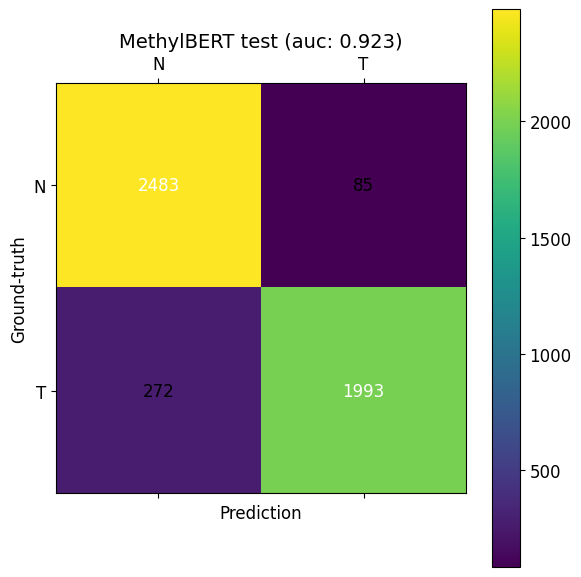

In [13]:
from sklearn.metrics import confusion_matrix, auc, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Set Matplotlib styling
plt.rcParams.update({
    "font.size": 12,
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "grid.color": "lightgray",
    "grid.linestyle": "-",
})

# Compute confusion matrix
cf_matrix = confusion_matrix(res.label_ids, res.predictions)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="viridis")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(j, i, f"{val}", ha="center", va="center", color="white" if val > cf_matrix.max() / 2 else "black")

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(res.label_ids, res.predictions)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"MethylBERT test (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
methylbert_formated_data = MethylBertFinetuneDataset(
                            data_source = synthetic_data,
                            vocab=MethylVocab(k=3),
                            seq_len=150
              )

In [ ]:
model_instance.predict(methylbert_formated_data)